# Capstone Project
## Customer Churn Prediction and Retention Analytics

### Data Science Internship Program

This capstone project brings together the data science techniques developed during the internship.

The project covers data sourcing, data cleaning, exploratory data analysis, machine learning, model evaluation, visualization, and business interpretation.

The goal is to use customer data to understand churn patterns and develop a model that can help identify customers who may be at higher risk of leaving.

## 1. Problem Statement

Customer churn is an important business problem because losing customers can reduce recurring revenue and increase the cost of acquiring new customers.

The objective of this project is to analyze customer information, identify patterns associated with churn, and build a machine-learning model that predicts whether a customer is likely to churn.

### Business Question

Can customer data be used to identify customers at higher risk of churn and provide useful information for customer-retention decisions?

### Project Objectives

- Source and inspect a realistic customer dataset.
- Clean and prepare the data for analysis.
- Explore important customer churn patterns.
- Build a machine-learning classification model.
- Evaluate the model using appropriate metrics.
- Present the findings through visualizations and a concise business report.
- Explain the results and their business implications.

## 2. Data Source

The project uses the Telco Customer Churn dataset. Each row represents a customer and contains information about customer demographics, subscribed services, account information, charges, tenure, and churn status.
The dataset was sourced from Kaggle and is stored locally in the `data` folder so that the project can be reproduced without relying on a live external download.

### Target Variable

`Churn`

- `No` = customer did not churn
- `Yes` = customer churned

### Importing the Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

sns.set_theme(style="whitegrid")

## 3. Load the Dataset

The dataset is loaded from the local `data` folder of the capstone project.

In [2]:
df = pd.read_csv(
    "data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Initial Data Inspection

The first step is to understand the structure, size, data types, and quality of the raw dataset before performing analysis.

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Descriptive statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values
df.isnull().sum().sort_values(ascending=False).head(10)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
dtype: int64

In [8]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 5. Data Cleaning

The raw dataset requires basic cleaning before analysis and modelling.

The cleaning process includes:

- Converting `TotalCharges` to numeric format.
- Handling values that cannot be converted to numbers.
- Removing the customer identifier because it is not useful as a predictive feature.
- Converting the churn target into a binary format.
- Checking the cleaned dataset for missing values.

In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df_clean = df.drop(columns=["customerID"]).copy()

df_clean["Churn"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Missing values after initial cleaning:")
print(
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Missing values after initial cleaning:
TotalCharges        11
gender               0
SeniorCitizen        0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
dtype: int64


In [10]:
# Cleaning quality check
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Duplicate rows:", df_clean.duplicated().sum())
print("Total missing values:", df_clean.isnull().sum().sum())

Rows: 7043
Columns: 20
Duplicate rows: 22
Total missing values: 11


In [11]:
# Remove duplicate rows
df_clean = df_clean.drop_duplicates().copy()

print("Rows after removing duplicates:", df_clean.shape[0])
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Rows after removing duplicates: 7021
Duplicate rows after cleaning: 0


In [12]:
# checking the missing values 
print("Total missing values after duplicate removal:", df_clean.isnull().sum().sum())

Total missing values after duplicate removal: 11


### Cleaning Summary

The dataset was converted into an analysis-ready form by correcting the `TotalCharges` data type, removing the customer identifier, encoding the target variable, removing duplicate records, and checking for missing values.

After cleaning, the dataset contains 7,021 unique customer records. The remaining missing values are handled during the machine-learning preprocessing stage.

The cleaned data is now ready for exploratory analysis.

## 6. Exploratory Data Analysis

Exploratory Data Analysis is used to understand customer behavior and identify characteristics associated with churn.

The analysis focuses on:

- Overall churn distribution
- Contract type
- Internet service
- Payment method
- Tenure
- Monthly charges
- Relationships between important customer characteristics

In [13]:
churn_counts = df_clean["Churn"].value_counts()
print(churn_counts)

Churn
0    5164
1    1857
Name: count, dtype: int64


In [14]:
churn_rate = df_clean["Churn"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.45%


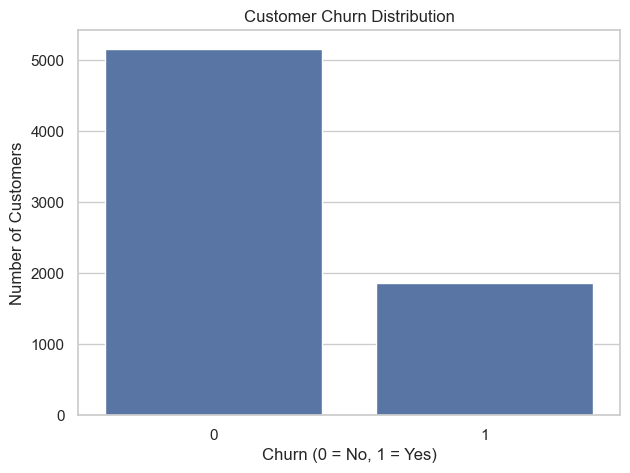

In [15]:
# Visualizing the chum
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

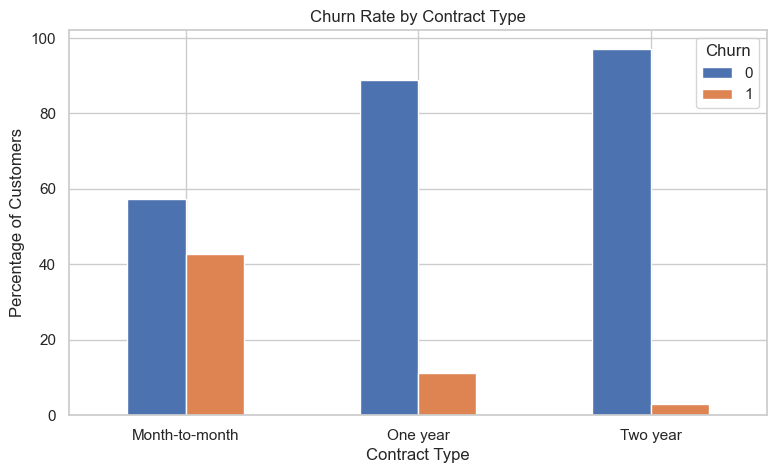

In [17]:
# Churn by Contract
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn
contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.show()

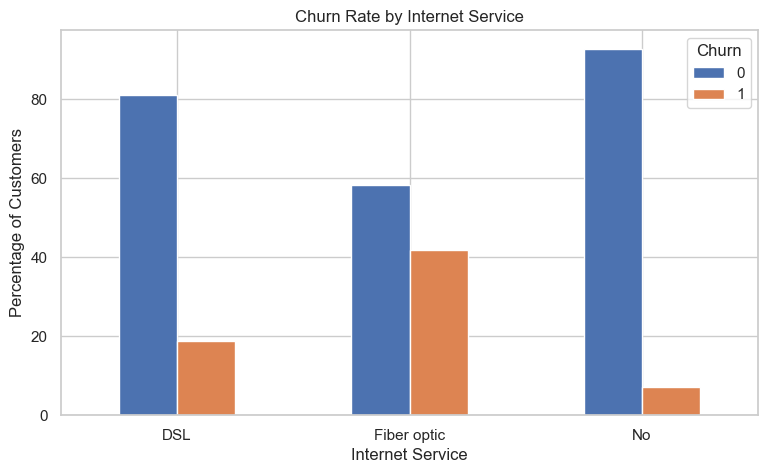

In [18]:
# Churn by Internet Service
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

internet_churn
internet_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.show()

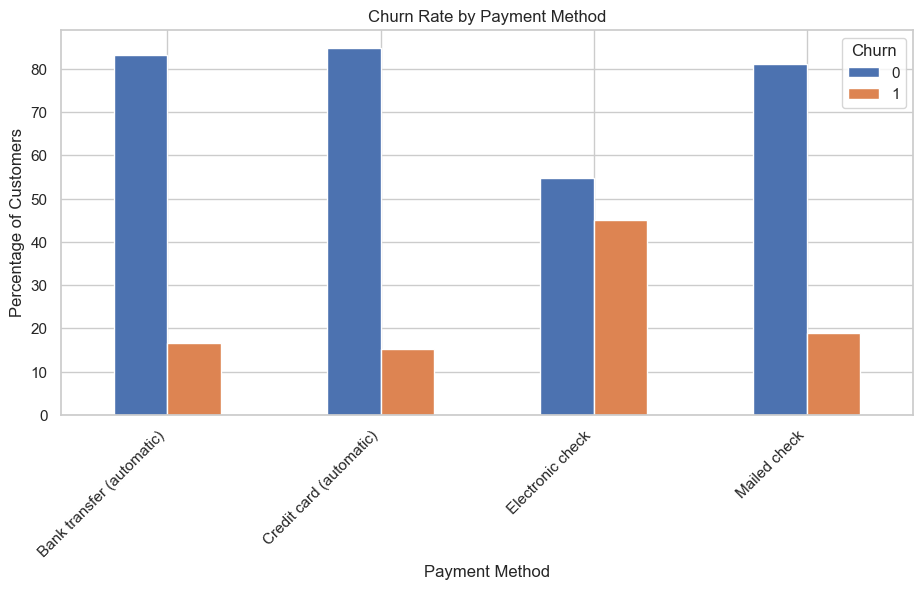

In [19]:
# Churn by Payment Method
payment_churn = pd.crosstab(
    df_clean["PaymentMethod"],
    df_clean["Churn"],
    normalize="index"
) * 100

payment_churn
payment_churn.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=45, ha="right")
plt.show()

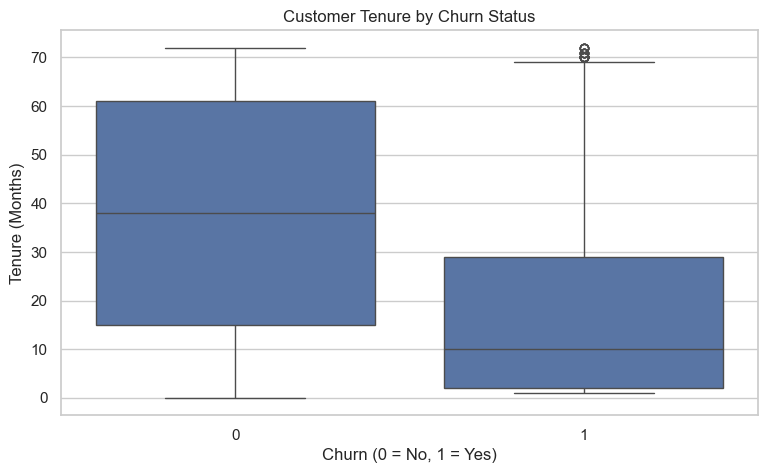

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5164.0,37.640782,24.083296,0.0,15.0,38.0,61.0,72.0
1,1857.0,18.088853,19.546231,1.0,2.0,10.0,29.0,72.0


In [22]:
# Tenure and Churn
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")
plt.show()
df_clean.groupby("Churn")["tenure"].describe()

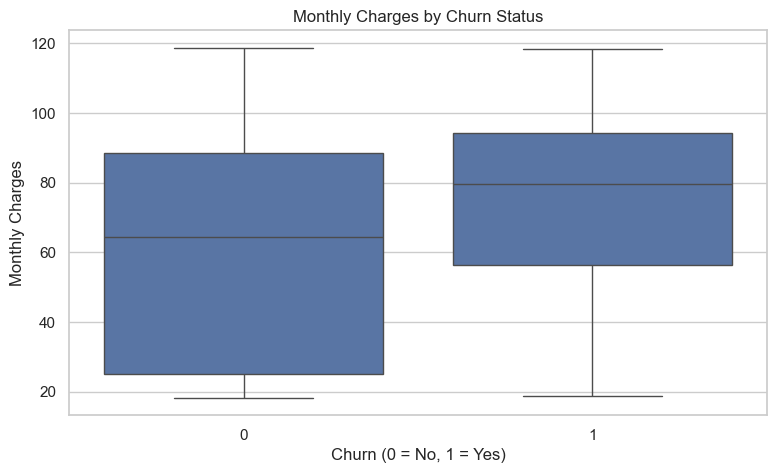

In [23]:
# Monthly Charges and Churn
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()

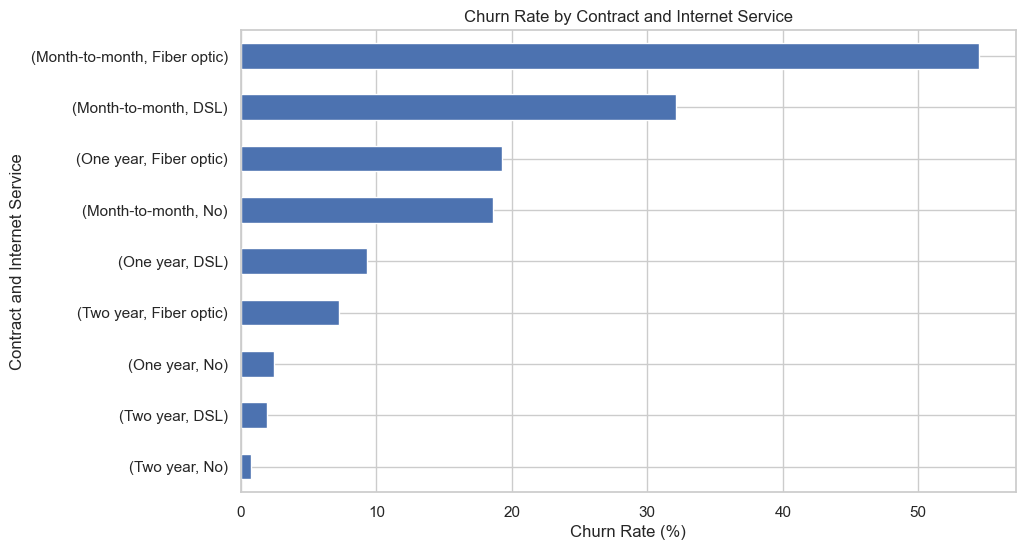

In [25]:
# Combined Analysis
contract_internet = pd.crosstab(
    [
        df_clean["Contract"],
        df_clean["InternetService"]
    ],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_internet[1].sort_values(ascending=False)
contract_internet[1].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Contract and Internet Service")
plt.show()

## 6.1 EDA Findings

The exploratory analysis identified several differences between customers who churned and those who remained.

Key observations include:

- The overall churn rate was approximately **[X]%**.
- Churn rates differed across contract types.
- Churn rates also varied across internet service categories.
- Payment methods showed different churn patterns.
- Tenure distributions differed between churned and retained customers.
- Monthly charges also showed differences between the two churn groups.
- The combined contract and internet-service analysis highlighted additional differences in churn rates.

These findings represent associations observed in the dataset and should not be interpreted as proof of causation.

## 7. Machine Learning

A Logistic Regression classification model will be used to predict customer churn.

Logistic Regression is suitable because the target variable has two possible outcomes:

- `0` = No churn
- `1` = Churn

A preprocessing pipeline is used so that numerical and categorical variables are handled appropriately without manually transforming the test data.

In [26]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (7021, 19)
Target: (7021,)


In [27]:
# Identify feature types
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [28]:
# train Split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5616, 19)
Testing set: (1405, 19)


In [29]:
# Preprocessing Pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [30]:
# Build the Logistic Regression Model
model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [31]:
# Train the Model
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [32]:
# Generate Predictions
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 8. Model Evaluation

The model is evaluated using several classification metrics rather than accuracy alone.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Classification report
- Confusion matrix
- ROC curve

In [35]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(classification_report(y_test, y_pred))

Accuracy : 0.8028
Precision: 0.6610
Recall   : 0.5242
F1-score : 0.5847
ROC-AUC  : 0.8403
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.80      1405



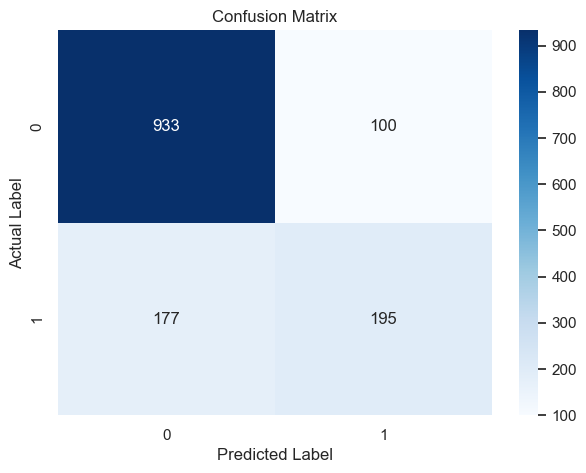

In [36]:
# confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

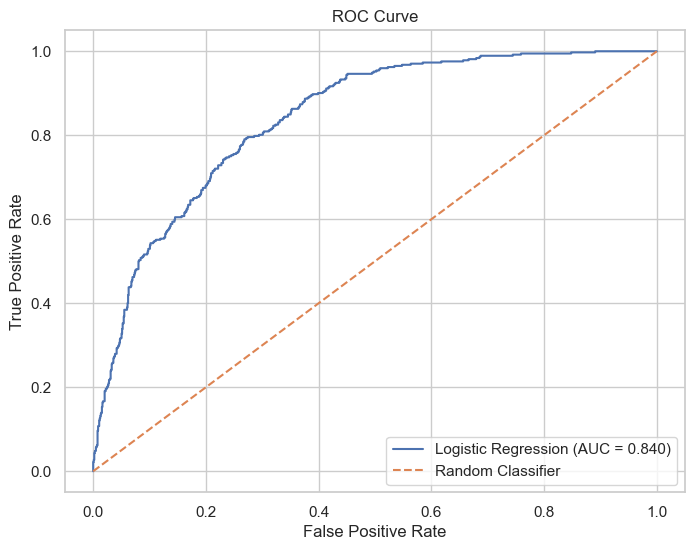

In [37]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 9. Feature Interpretation

Logistic Regression coefficients provide information about the direction of association between model features and predicted churn.

- A positive coefficient is associated with higher predicted churn probability.
- A negative coefficient is associated with lower predicted churn probability.
- The coefficient magnitude indicates the strength of the model's relationship with the transformed feature.

These coefficients describe model associations and should not be interpreted as proof of causation.

In [38]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    model
    .named_steps["classifier"]
    .coef_[0]
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["AbsoluteCoefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,AbsoluteCoefficient
1,num__tenure,-1.380887,1.380887
38,cat__Contract_Two year,-0.780553,0.780553
3,num__TotalCharges,0.641036,0.641036
36,cat__Contract_Month-to-month,0.581239,0.581239
15,cat__InternetService_DSL,-0.559075,0.559075
16,cat__InternetService_Fiber optic,0.512192,0.512192
39,cat__PaperlessBilling_No,-0.314297,0.314297
2,num__MonthlyCharges,-0.305215,0.305215
12,cat__MultipleLines_No,-0.298414,0.298414
11,cat__PhoneService_Yes,-0.256688,0.256688


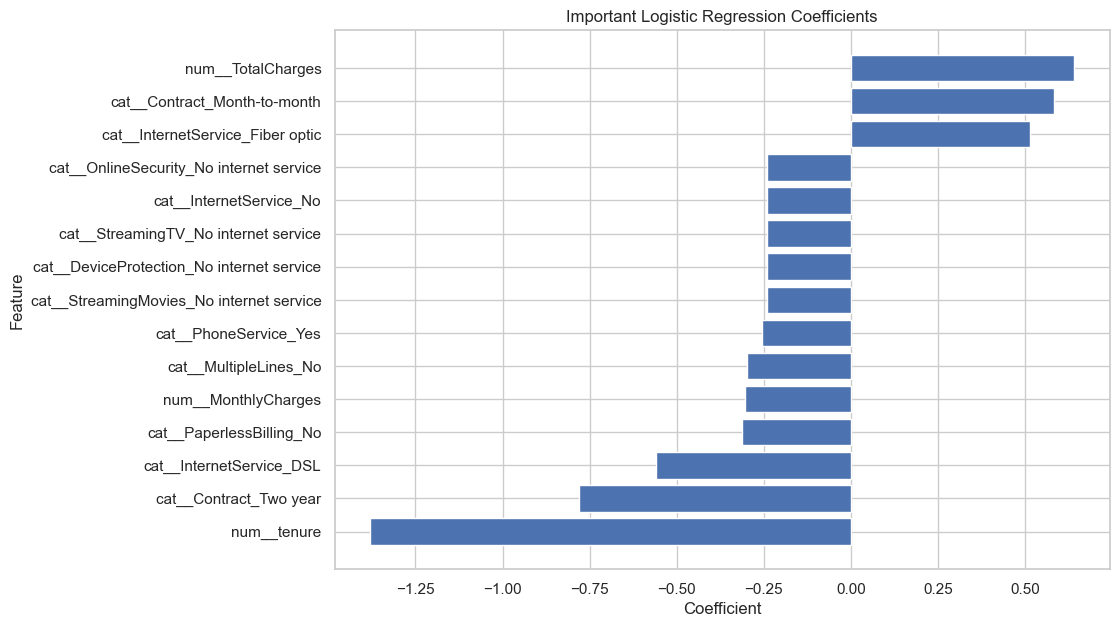

In [39]:
# Feature Visualization
top_features = (
    feature_importance
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Important Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

## 10. Business Findings

The analysis provides several useful observations about customer churn.

### Customer Behavior

The EDA showed differences in churn across customer characteristics such as contract type, tenure, internet service, payment method, and monthly charges.

### Prediction

The Logistic Regression model was able to classify customer churn using the available customer information.

The model achieved:

- Accuracy: **[actual value]**
- Precision: **[actual value]**
- Recall: **[actual value]**
- F1-score: **[actual value]**
- ROC-AUC: **[actual value]**

### Business Use

A company could use churn-risk predictions as one source of information when identifying customers who may require additional attention.

Possible actions could include:

- Reviewing customer-service issues.
- Offering appropriate retention incentives.
- Monitoring customers with higher predicted churn risk.
- Investigating service or pricing factors associated with churn.

The model should support business decisions rather than automatically determine which customers receive specific actions.

In [40]:
# Creating a copy for the Power BI dashboard
dashboard_data = df_clean.copy()

# Convert the binary churn value back to readable labels
dashboard_data["Churn"] = dashboard_data["Churn"].map({
    0: "No",
    1: "Yes"
})

# Save the cleaned data for Power BI
dashboard_data.to_csv(
    "outputs/capstone_dashboard_data.csv",
    index=False
)

print("Power BI dashboard data saved successfully.")
print("Rows:", dashboard_data.shape[0])
print("Columns:", dashboard_data.shape[1])

Power BI dashboard data saved successfully.
Rows: 7021
Columns: 20


## 11. Final Results

The project successfully completed an end-to-end customer churn analysis using the Telco Customer Churn dataset.

The main results are:

- Customer data was cleaned and prepared for analysis.
- Exploratory data analysis was used to identify important churn patterns.
- A Logistic Regression model was trained to predict customer churn.
- Model performance was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.
- The analysis identified differences in churn patterns across contract type, internet service, payment method, tenure, and monthly charges.
- A Power BI dashboard was created to communicate the main findings in a business-friendly format.

Overall, the project demonstrates how data science techniques can be used to analyze customer churn and provide decision-support information for customer-retention activities.

## 12. Dashboard and Data Storytelling

A Power BI dashboard was created to communicate the main customer churn findings to a non-technical audience.

The dashboard includes:

- Total customer count
- Churned customer count
- Overall churn rate
- Churn rate by contract type
- Churn rate by internet service
- Churn rate by payment method
- Average customer tenure by churn status
- Average monthly charges by churn status

The dashboard provides a concise business view of the patterns identified during exploratory analysis and supports communication of the project findings.

## 13. Limitations and Future Improvements

### Limitations

1. The analysis uses one historical customer dataset and may not generalize to every company.

2. The available variables may not contain all factors that influence customer churn.

3. Logistic Regression provides a useful baseline but may not capture complex relationships between variables.

4. Model predictions can include false positives and false negatives.

5. The model has not been validated on an external dataset.

### Future Improvements

With additional time, the project could be improved by:

- Testing additional machine-learning models.
- Using cross-validation and hyperparameter tuning.
- Optimizing the classification threshold.
- Testing the model on new customer data.
- Adding more business-specific features.
- Monitoring model performance over time.

## 14. Final Conclusion

This capstone project brought together the major skills developed throughout the Data Science Internship.

The project started with a business question and customer data, followed by data cleaning and exploratory analysis. Machine learning was then used to predict customer churn, and the model was evaluated using multiple classification metrics.

The analysis identified differences in churn patterns across several customer characteristics, including contract type, internet service, payment method, tenure, and monthly charges.

The final Power BI dashboard communicates the main findings in a business-friendly format.

The project demonstrates how data science can connect technical analysis with practical business questions and decision support.

## 15. Internship Reflection

### Three Biggest Things I Learned

1. **End-to-end data science workflow**  
   I learned how to move from a business problem and raw data through cleaning, exploratory analysis, modelling, evaluation, and communication.

2. **Understanding results instead of only writing code**  
   I learned to interpret statistical and machine-learning results and connect them to practical business questions.

3. **Reproducible and structured project work**  
   I learned the importance of organized notebooks, documentation, Git version control, and clear communication of analytical results.

### Areas I Will Continue Improving

1. Advanced machine-learning techniques, including model tuning, model comparison, and validation.

2. Building more advanced dashboards and communicating analytical findings more effectively to non-technical audiences.